Table of contents:
1. Load Data
2. Preprocessing

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
!pip install scikeras

# 1. Load Data

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/clean/clean_df.csv')

In [5]:
df.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'LoanDate', 'Age', 'AppliedAmount', 'Amount',
       'Interest',
       ...
       'OccupationArea_11.0', 'OccupationArea_12.0', 'OccupationArea_13.0',
       'OccupationArea_14.0', 'OccupationArea_15.0', 'OccupationArea_16.0',
       'OccupationArea_17.0', 'OccupationArea_18.0', 'OccupationArea_19.0',
       'Default'],
      dtype='object', length=109)

# 2. Data Preprocessing

In [6]:
df['UserName'].nunique()

44258

In [7]:
df['LoanDate'].min(), df['LoanDate'].max()

('2009-02-28', '2020-01-23')

In [8]:
def process_and_split_temporal_by_date(df, cutoff_date='2019-01-01', time_col='LoanDate', group_col='UserName'):
    # 1. Đảm bảo cột thời gian đúng định dạng datetime
    df[time_col] = pd.to_datetime(df[time_col])
    cutoff_dt = pd.to_datetime(cutoff_date)

    # 2. Tạo cột loan_nth (khoản vay thứ N của mỗi khách hàng)
    df = df.sort_values(by=[group_col, time_col]).reset_index(drop=True)
    df['loan_nth'] = df.groupby(group_col).cumcount() + 1

    # 3. Chia tập Train và Test theo mốc ngày cutoff
    df_train = df[df[time_col] < cutoff_dt].copy()
    df_test = df[df[time_col] >= cutoff_dt].copy()

    return df_train, df_test, cutoff_dt

# Thực thi
cutoff_input = '2019-01-01'
df_train, df_test, cutoff = process_and_split_temporal_by_date(
    df, cutoff_date=cutoff_input, time_col='LoanDate', group_col='UserName'
)

# Kết quả
print(f"Mốc thời gian chia (Cutoff date): {cutoff.strftime('%Y-%m-%d')}")
print(f"Train size: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_test)):.2%})")
print(f"Test size: {len(df_test)} ({len(df_test)/(len(df_train)+len(df_test)):.2%})")

Mốc thời gian chia (Cutoff date): 2019-01-01
Train size: 58280 (75.30%)
Test size: 19114 (24.70%)


In [9]:
df_train = df_train.sort_values(by=['LoanDate'])
df_test = df_test.sort_values(by=['LoanDate'])
X_train = df_train.drop(columns=['Default', 'LoanDate', 'UserName'])
y_train = df_train['Default']
X_test = df_test.drop(columns=['Default', 'LoanDate', 'UserName'])
y_test = df_test['Default']

In [10]:
X_train.shape

(58280, 107)

In [11]:
transform_features = [
    # Tiền tệ & Thu nhập
    'AppliedAmount', 'Amount', 'MonthlyPayment', 'IncomeTotal',
    'IncomeFromPrincipalEmployer', 'IncomeFromPension', 'IncomeFromFamilyAllowance',
    'IncomeFromSocialWelfare', 'IncomeFromLeavePay', 'IncomeFromChildSupport',
    'IncomeOther', 'FreeCash', 'BidsPortfolioManager', 'BidsApi', 'BidsManual',

    # Dư nợ, lãi suất & Lịch sử vay
    'DebtToIncome', 'Interest', 'ExistingLiabilities', 'LiabilitiesTotal',
    'RefinanceLiabilities', 'NoOfPreviousLoansBeforeLoan',
    'AmountOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan',
    'PreviousEarlyRepaymentsBeforeLoan', 'PreviousEarlyRepaymentsCountBeforeLoan',

    # Tuổi & Thời hạn
    'Age', 'LoanDurationDays'
]

In [12]:
def visualize_dis(df, features):
  df = df[features]
  int64_features = df.select_dtypes(include='int64').columns
  float64_features = df.select_dtypes(include='float64').columns

  num_plots = len(int64_features) + len(float64_features)
  cols = 4  # Adjust number of columns as needed
  rows = (num_plots + cols - 1) // cols

  fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
  axes = axes.flatten()

  for i, feature in enumerate(int64_features):
      sns.histplot(df[feature], ax=axes[i], kde=True)
      axes[i].set_title(feature)

  for i, feature in enumerate(float64_features):
      sns.histplot(df[feature], ax=axes[i + len(int64_features)], kde=True)
      axes[i + len(int64_features)].set_title(feature)

  for j in range(i + len(int64_features) + 1, len(axes)):
    axes[j].set_visible(False) # Hide any unused subplots

  plt.tight_layout()
  plt.show()

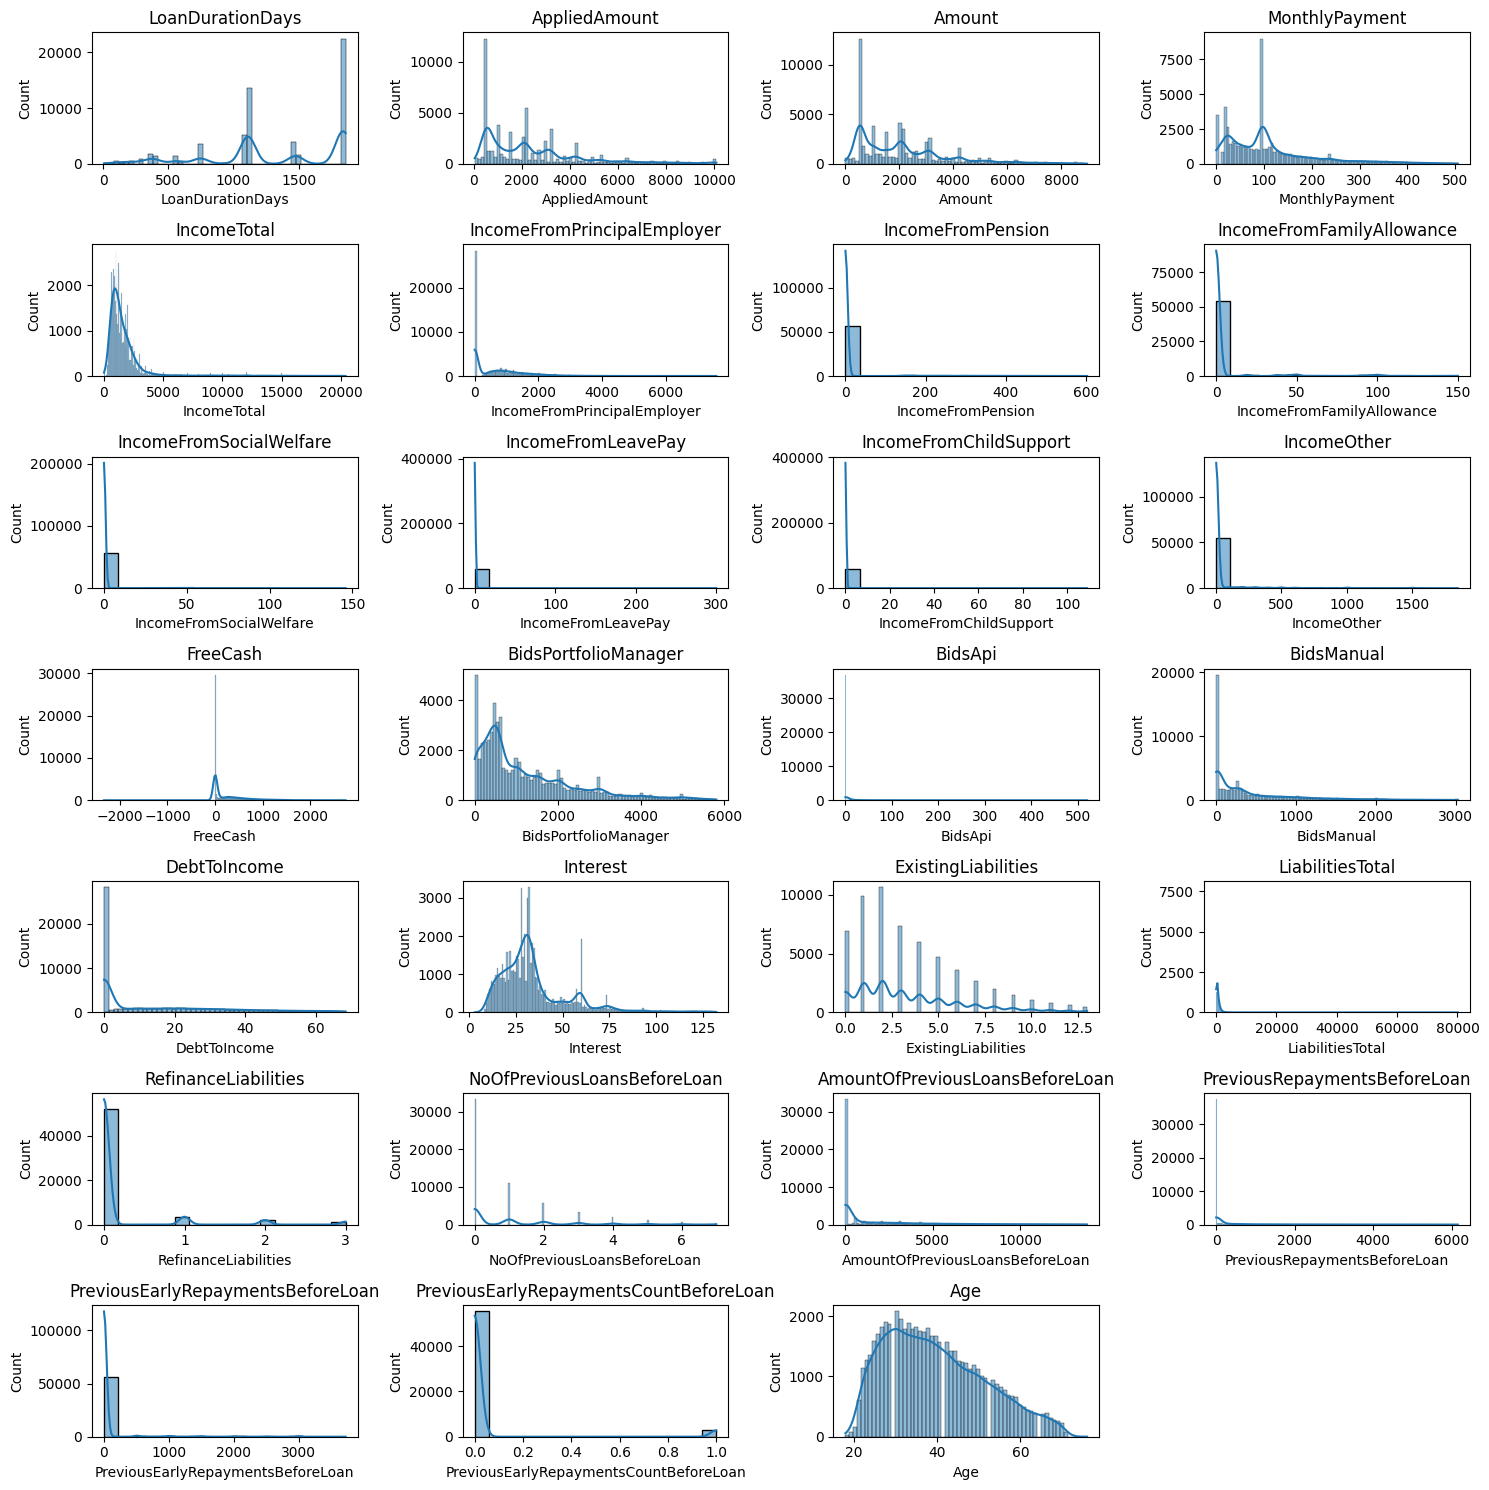

In [13]:
visualize_dis(X_train, transform_features)

In [14]:
# Right-skewed features
log_features = [
    'IncomeFromPension', 'IncomeFromFamilyAllowance', 'IncomeFromSocialWelfare',
    'IncomeFromLeavePay', 'IncomeFromChildSupport', 'IncomeOther',
    'AmountOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan',
    'PreviousEarlyRepaymentsBeforeLoan', 'LiabilitiesTotal', 'BidsApi'
]

# Áp dụng log1p (tương đương log(x + 1) để tránh lỗi log(0))
for col in log_features:
    X_train[col] = np.log1p(np.maximum(0, X_train[col]))

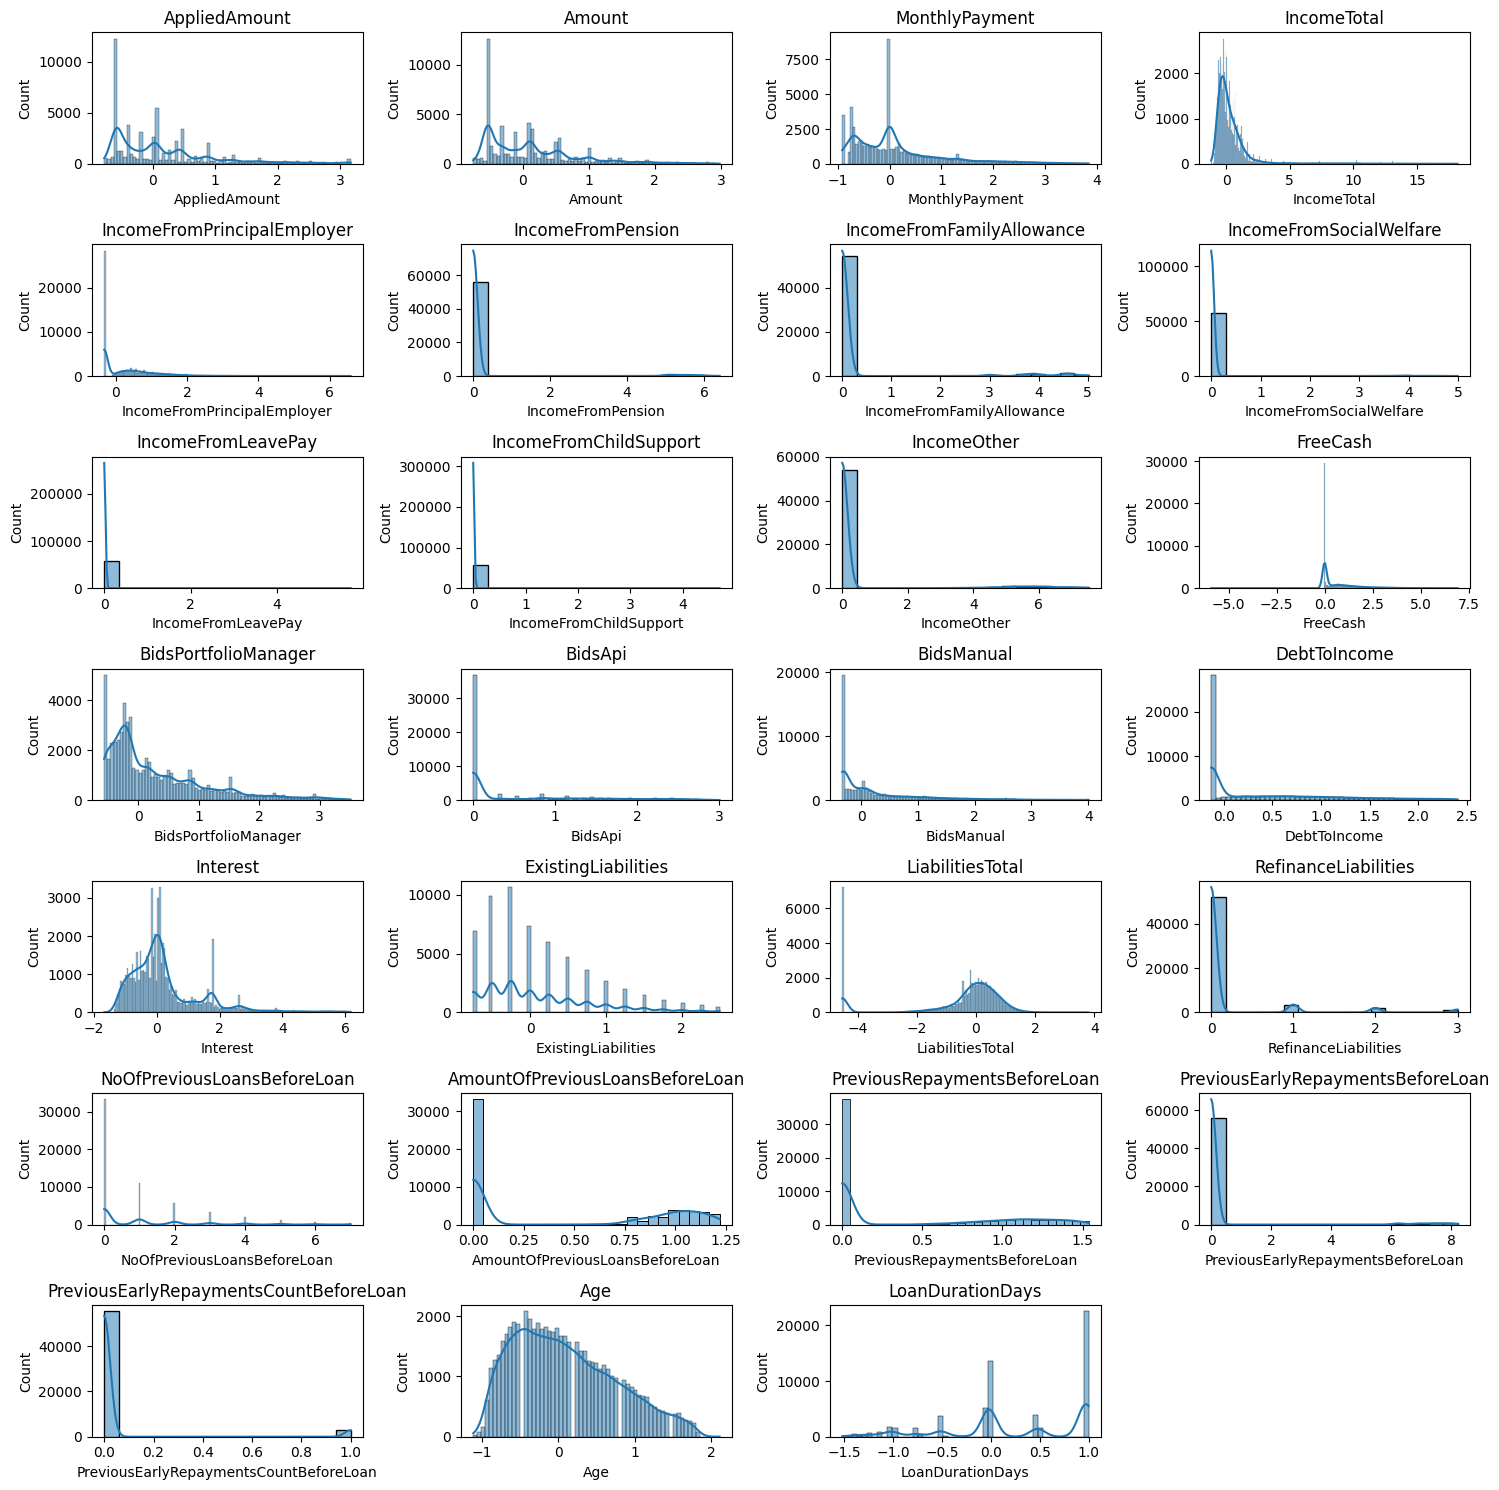

In [15]:
# 1.RobustScaler
scaler = RobustScaler()

# 2. Fit & Transform
X_train[transform_features] = scaler.fit_transform(X_train[transform_features])

visualize_dis(X_train, transform_features)

In [16]:
X_train[transform_features].head()

,AppliedAmount,Amount,MonthlyPayment,IncomeTotal,IncomeFromPrincipalEmployer,IncomeFromPension,IncomeFromFamilyAllowance,IncomeFromSocialWelfare,IncomeFromLeavePay,IncomeFromChildSupport,...,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan,PreviousEarlyRepaymentsBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,Age,LoanDurationDays
71283,-0.541523,-0.617602,0.0,7.364326,-0.318182,0.0,0.0,0.0,0.0,0.0,...,-0.75,-4.528008,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.016260
72965,-0.616713,-0.722791,0.0,10.210626,-0.318182,0.0,0.0,0.0,0.0,0.0,...,-0.75,-4.528008,0.0,0.0,0.0,0.0,0.0,0.0,-0.444444,-1.261518
73061,-0.742030,-0.698824,0.0,3.474383,3.318182,0.0,0.0,0.0,0.0,0.0,...,-0.75,-4.528008,0.0,0.0,0.0,0.0,0.0,0.0,-0.166667,-1.449864
70935,-0.416206,-0.717466,0.0,2.620493,3.318182,0.0,0.0,0.0,0.0,0.0,...,-0.75,-4.528008,0.0,0.0,0.0,0.0,0.0,0.0,-1.000000,-0.520325
154,-0.416206,-0.646896,0.0,4.518027,5.136364,0.0,0.0,0.0,0.0,0.0,...,-0.75,-4.528008,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,-0.495935


In [17]:
# 4. Transform trên tập Test
X_test[transform_features] = scaler.transform(X_test[transform_features])

In [18]:
X_train.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'NewCreditCustomer',
       'Age', 'AppliedAmount', 'Amount', 'Interest', 'LoanDuration',
       'MonthlyPayment',
       ...
       'OccupationArea_11.0', 'OccupationArea_12.0', 'OccupationArea_13.0',
       'OccupationArea_14.0', 'OccupationArea_15.0', 'OccupationArea_16.0',
       'OccupationArea_17.0', 'OccupationArea_18.0', 'OccupationArea_19.0',
       'loan_nth'],
      dtype='object', length=107)

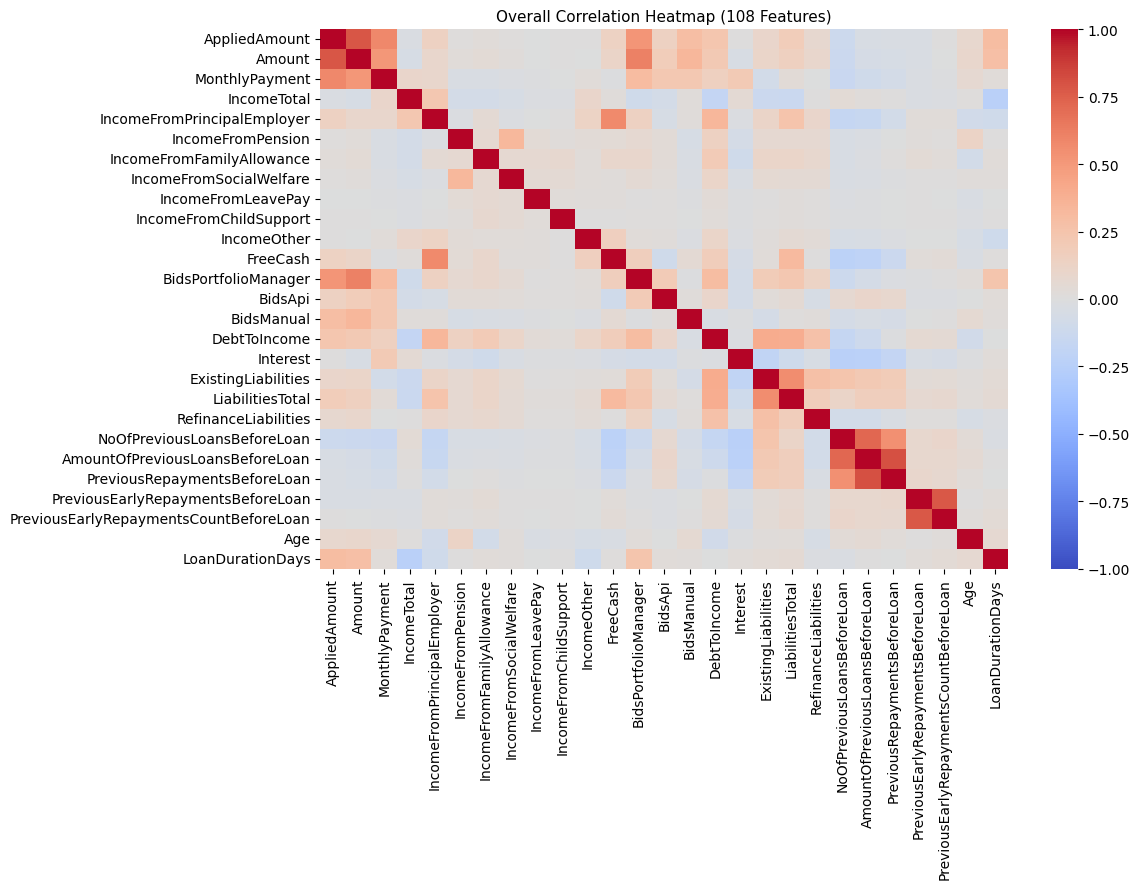

In [19]:
# 1. Tính ma trận correlation cho tất cả các cột số
corr_matrix = X_train[transform_features].corr()

# 2. Vẽ Heatmap kích thước lớn
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=False,         # Tắt số để tránh bị đè chữ lên nhau
    cmap='coolwarm',
    vmin=-1, vmax=1,
    xticklabels=True,   # Tắt label x/y nếu chữ quá chật (hoặc để True nếu muốn xem)
    yticklabels=True
)
plt.title('Overall Correlation Heatmap (108 Features)', fontsize=11)
plt.tight_layout()
plt.show()

Biến có tương quan cao:
- Amount vs AppliedAmount vs MonthlyPayment: Actual amount borrowed vs received vs estimated monthly split payment
- NoOfPreviousLoansBeforeLoan vs AmountOfPreviousLoansBeforeLoan
- PreviousEarlyRepaymentsBeforeLoan và PreviousEarlyRepaymentsCountBeforeLoan
- IncomeTotal và IncomeFromPrincipalEmployer
- ExistingLiabilities và LiabilitiesTotal
- Drop:
`"AppliedAmount", "MonthlyPayment", "NoOfPreviousLoansBeforeLoan", "PreviousEarlyRepaymentsCountBeforeLoan","IncomeFromPrincipalEmployer","IncomeFromPension", "IncomeFromFamilyAllowance", "IncomeFromSocialWelfare", "IncomeFromLeavePay", "IncomeFromChildSupport"`

In [20]:
high_corr_features = ["AppliedAmount", "MonthlyPayment", "NoOfPreviousLoansBeforeLoan", "PreviousEarlyRepaymentsCountBeforeLoan","IncomeFromPrincipalEmployer","IncomeFromPension", "IncomeFromFamilyAllowance", "IncomeFromSocialWelfare", "IncomeFromLeavePay", "IncomeFromChildSupport"]
X_train.drop(columns=high_corr_features, inplace=True)
X_test.drop(columns=high_corr_features, inplace=True)

In [25]:
def find_high_vif(X, threshold=10):
  # Loại bỏ NaN và biến target trước khi tính
  vif_check = X.dropna()

  vif_data = pd.DataFrame()
  vif_data["Feature"] = vif_check.columns
  vif_data["VIF"] = [variance_inflation_factor(vif_check.values, i) for i in range(vif_check.shape[1])]

  # Lọc các feature có VIF cao
  high_vif = vif_data[vif_data["VIF"] > 10].sort_values(by="VIF", ascending=False)
  print(high_vif)
  return high_vif['Feature'].tolist()

In [26]:
high_vif_lst = find_high_vif(X_train, threshold=10)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                  Feature         VIF
7            LoanDuration  270.460233
27             Country_ES  112.297214
34         LanguageCode_6  106.002076
26  CreditScoreNormalized   47.267211
20       LoanDurationDays   42.861256
28             Country_FI   42.204972
32         LanguageCode_4   38.207163
61   VerificationType_4.0   37.932530
58   VerificationType_1.0   26.154091
8               Education   13.879952
60   VerificationType_3.0   11.879032
3       NewCreditCustomer   11.628164
22          Rating_OrdEnc   10.475266


In [27]:
X_train.drop(columns=high_vif_lst, inplace=True)
X_test.drop(columns=high_vif_lst, inplace=True)

In [28]:
high_vif_lst = find_high_vif(X_train, threshold=5)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Empty DataFrame
Columns: [Feature, VIF]
Index: []


In [29]:
X_train.shape

(58280, 84)

In [33]:
X_train['UserName']

KeyError: 'UserName'

In [30]:
X_train.to_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/X_train.csv',index=False)
y_train.to_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/y_train.csv',index=False)
X_test.to_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/X_test.csv',index=False)
y_test.to_csv('/content/drive/MyDrive/Research/Paper: Enhancing Default Prediction in P2P Lending with Deep Model Fusion/Source Code/data/y_test.csv',index=False)